# 一、实例方法
1. 定义：第一个参数必须是 self（代表类的实例本身），通过 self 可以访问 / 修改实例属性和类属性。
2. 调用：必须通过类的实例（对象）调用。

In [1]:
class Student:
    # 类属性：所有实例共享
    school = "北京大学"

    def __init__(self, name, score):
        # 实例属性：每个实例独有
        self.name = name
        self.score = score

    # 实例方法
    def get_score(self):
        # 通过self访问实例属性
        return f"{self.name}的分数是：{self.score}"

# 调用实例方法：必须先创建实例
stu1 = Student("张三", 90)
print(stu1.get_score())  # 输出：张三的分数是：90

张三的分数是：90


# 二、类方法（@classmethod）
1. 定义与核心特点
    - 用 @classmethod 装饰器标记，第一个参数固定为 cls（代表类本身，而非实例）。
    - 可以通过 cls 访问 / 修改类属性，但不能直接访问实例属性（因为没有 self）。
    - 调用方式：既可以通过类直接调用，也可以通过实例调用（推荐用类调用）。
2. 示例

In [4]:
class Student:
    school = "北京大学"
    # 类属性：统计学生总数
    total_students = 0

    def __init__(self, name, score):
        self.name = name
        self.score = score
        # 每创建一个实例，总数+1
        Student.total_students += 1

    # 类方法：用@classmethod装饰，参数是cls
    @classmethod
    def get_total(cls):
        # 通过cls访问类属性（等价于Student.total_students）
        return f"当前学生总数：{cls.total_students}"

    # 类方法的经典用途：工厂方法（创建实例的便捷方式）
    @classmethod
    def create_fail_student(cls, name):
        # 快速创建“不及格”的学生实例（分数固定为59）
        return cls(name, 59)

class XiaoMing(Student):
    def __init__(self, name, score):
        super().__init__(name, score)


# 1. 直接通过类调用类方法（推荐）
print(Student.get_total())  # 输出：当前学生总数：0

# 2. 创建实例
stu1 = Student("张三", 90)
stu2 = Student("李四", 85)
print(Student.get_total())  # 输出：当前学生总数：2

# 3. 用工厂方法创建实例（类方法的核心用处之一）
stu3 = Student.create_fail_student("王五")
print(stu3.score)  # 输出：59
print(Student.get_total())  # 输出：当前学生总数：3

# 4. 也可以通过实例调用类方法（不推荐，语义不清晰）
print(stu1.get_total())  # 输出：当前学生总数：3

# 5. XiaoMing继承自Student，可直接：子类类名.父类类方法
xiaoMing = XiaoMing("小明",98)
print(XiaoMing.get_total())

当前学生总数：0
当前学生总数：2
59
当前学生总数：3
当前学生总数：3
当前学生总数：4


3. 核心用处：
    - 操作类属性：需要修改 / 访问类的共享属性（如统计总数、修改全局配置）时，用类方法更符合语义（明确表示操作 “类” 而非 “实例”）。
    - 工厂方法：创建实例的便捷方式（比如根据不同参数快速生成实例，避免重复写 \_\_init__ 逻辑）。
    - 继承场景：子类继承后，cls 会自动指向子类，而非父类（静态方法无此特性），适合实现多态逻辑。

# 三、静态方法（@staticmethod）
1. 定义与核心特点
    - 用 @staticmethod 装饰器标记，没有默认的 self 或 cls 参数（和普通函数一样）。
    - 既不能访问实例属性，也不能直接访问类属性（除非显式传入类 / 实例）。
    - 本质：是类命名空间下的 “普通函数”，只是逻辑上属于这个类，用于代码组织（避免全局函数混乱）。
    - 调用方式：同样可以通过类或实例调用（推荐用类调用）。
2. 示例：

In [5]:
class Student:
    school = "北京大学"

    def __init__(self, name, student_id):
        # 先验证学号格式，再赋值
        if not Student.is_valid_id(student_id):
            raise ValueError("学号格式错误！必须是6位数字")
        self.name = name
        self.student_id = student_id

    # 静态方法：验证学号格式
    @staticmethod
    def is_valid_id(student_id):
        # 逻辑：学号必须是6位数字
        return isinstance(student_id, str) and len(student_id) == 6 and student_id.isdigit()

# 1. 直接通过类调用静态方法（工具函数特性）
print(Student.is_valid_id("123456"))  # 输出：True
print(Student.is_valid_id("12345"))   # 输出：False

# 2. 创建实例（内部调用静态方法验证）
stu1 = Student("张三", "123456")  # 正常创建
# stu2 = Student("李四", "12345")  # 抛出ValueError：学号格式错误！

True
False


3. 核心用处：
    - 类的工具函数：逻辑与类 / 实例属性无关，但属于类的 “配套功能”（如格式验证、数据计算、辅助工具）。
    - 代码组织：将相关的函数封装到类中，避免全局函数泛滥，提高代码可读性和维护性。
    - 无状态逻辑：不需要访问类 / 实例的任何状态，仅依赖传入的参数完成逻辑。

# 四、核心对比
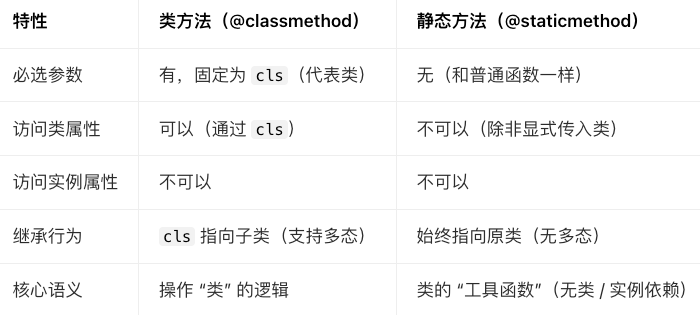

- 继承场景

In [6]:
class Parent:
    @classmethod
    def cls_method(cls):
        print(f"类方法：{cls.__name__}")

    @staticmethod
    def static_method():
        print(f"静态方法：{Parent.__name__}")

class Child(Parent):
    pass

# 类方法：cls指向子类Child
Child.cls_method()    # 输出：类方法：Child
# 静态方法：仍指向父类Parent
Child.static_method() # 输出：静态方法：Parent

类方法：Child
静态方法：Parent


- 综合示例

In [7]:
class Circle:
    # 类属性：圆周率
    PI = 3.14159

    def __init__(self, radius):
        # 实例属性：半径
        self.radius = radius

    # 1. 实例方法：依赖实例属性（半径）
    def get_area(self):
        return self.PI * self.radius **2

    # 2. 类方法：修改类属性（圆周率）
    @classmethod
    def set_pi(cls, new_pi):
        cls.PI = new_pi

    # 3. 静态方法：工具函数（计算两个圆的半径和）
    @staticmethod
    def add_radius(r1, r2):
        return r1 + r2

# 1. 实例方法调用
c1 = Circle(5)
print(c1.get_area())  # 输出：78.53975

# 2. 类方法调用（修改圆周率）
Circle.set_pi(3.14)
print(c1.get_area())  # 输出：78.5（圆周率已修改）

# 3. 静态方法调用（工具函数）
print(Circle.add_radius(5, 3))  # 输出：8

78.53975
78.5
8
